# **Ruya: A Smart Sales Analysis and Forecasting System for Coffee Shops**

The goal of this project is to build a data-driven system that helps café owners analyze their
sales data, understand customer behavior, predict future trends, and make better business
decisions. Ruya aims to support business growth by offering actionable insights, profit-
boosting recommendations, and performance tracking overtime.

[🔗 Coffee Sales Dataset](https://www.kaggle.com/datasets/navjotkaushal/coffee-sales-dataset/data)

### 1. Loading Dataset from Local File

In [15]:
import pandas as pd
import os

# Set the path to your coffee sales dataset
file_path = r"c:\Users\dxgam\OneDrive\سطح المكتب\Games\Coffe_sales.csv"

# Load the dataset
df = pd.read_csv(file_path)

print(f"\n✓ File loaded successfully!")
print(f"Shape: {df.shape}")
df.head()


✓ File loaded successfully!
Shape: (3547, 11)


,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


# **Data Prepping**

--> Objectives:

1.   Standardize column names for consistency.
2.   Convert date and time columns to proper datetime format for analysis.
3.  Inspect the dataset to ensure the conversions were successful.

In [16]:
print(" Understanding the dataset...\n")

print("➡ Shape (rows, columns):")
print(df.shape)

print("\n➡ Column Names:")
print(df.columns)

print("\n➡ Sample Rows:")
display(df.head())

print("\n➡ Data Types:")
df.info()

print("\n➡ Summary of numeric values:")
display(df.describe())

 Understanding the dataset...

➡ Shape (rows, columns):
(3547, 11)

➡ Column Names:
Index(['hour_of_day', 'cash_type', 'money', 'coffee_name', 'Time_of_Day',
       'Weekday', 'Month_name', 'Weekdaysort', 'Monthsort', 'Date', 'Time'],
      dtype='object')

➡ Sample Rows:


,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000



➡ Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB

➡ Summary of numeric values:


,hour_of_day,money,Weekdaysort,Monthsort
count,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905
std,4.234010,4.877754,1.971501,3.500754
min,6.000000,18.120000,1.000000,1.000000
25%,10.000000,27.920000,2.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000
75%,18.000000,35.760000,6.000000,10.000000
max,22.000000,38.700000,7.000000,12.000000


In [17]:
print(" Cleaning and standardizing columns...")

# Standardize column names (lowercase, no spaces)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Convert 'date' to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Convert 'time' to datetime (if your time column is HH:MM:SS or HH:MM:SS.mmm)
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S.%f', errors='coerce')

# Preview the dataset after conversion
df.info()
df.head()


 Cleaning and standardizing columns...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   hour_of_day  3547 non-null   int64         
 1   cash_type    3547 non-null   object        
 2   money        3547 non-null   float64       
 3   coffee_name  3547 non-null   object        
 4   time_of_day  3547 non-null   object        
 5   weekday      3547 non-null   object        
 6   month_name   3547 non-null   object        
 7   weekdaysort  3547 non-null   int64         
 8   monthsort    3547 non-null   int64         
 9   date         3547 non-null   datetime64[ns]
 10  time         3539 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(3), object(5)
memory usage: 304.9+ KB


,hour_of_day,cash_type,money,coffee_name,time_of_day,weekday,month_name,weekdaysort,monthsort,date,time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,1900-01-01 10:15:50.520
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,1900-01-01 12:19:22.539
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,1900-01-01 12:20:18.089
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,1900-01-01 13:46:33.006
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,1900-01-01 13:48:14.626


In [18]:
#the dataset has 8 rows with Nat cells for time, so I decided to drop these rows
df = df.dropna(subset=['time'])
df['datetime'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'].dt.time.astype(str))


In [19]:
# Combine date + time into one datetime column
df['datetime'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'].dt.time.astype(str))

# Preview
df[['date', 'time', 'datetime']].head()


,date,time,datetime
0,2024-03-01,1900-01-01 10:15:50.520,2024-03-01 10:15:50.520
1,2024-03-01,1900-01-01 12:19:22.539,2024-03-01 12:19:22.539
2,2024-03-01,1900-01-01 12:20:18.089,2024-03-01 12:20:18.089
3,2024-03-01,1900-01-01 13:46:33.006,2024-03-01 13:46:33.006
4,2024-03-01,1900-01-01 13:48:14.626,2024-03-01 13:48:14.626


In [20]:
#Drop time to avoid confusion.
df = df.drop(columns=['time'])

**Summary of the step above:**

- Identified 8 rows with missing time values
- Dropped 8 rows where time was missing
- Created a new datetime column combining date + time
- Dropped the original time column to avoid confusion

---
**Current Dataset State**
- Rows: 3539 (after dropping 8 rows)
- Columns: 11 original + 1 new (datetime) → 12 columns
- time column removed
- datetime column represents actual date + time of each sale

# **Feature Engineering**

What this cell does:

Creates year, month, day → useful for grouping and trends

Creates weekday → helps analyze busiest days

Creates hour, minute → helps analyze busiest hours

Drops the old time column → avoids confusion

Prints a preview and info → so you can confirm everything worked

In [21]:
print(" Feature Engineering & Cleaning for final dataset...")

# Extract useful features from 'datetime'
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month        # numeric month (1-12)
df['day'] = df['datetime'].dt.day           # numeric day (1-31)
df['weekday_name'] = df['datetime'].dt.day_name()

# Select lean final column set
final_columns = [
    'datetime',
    'hour_of_day',
    'cash_type',
    'money',
    'coffee_name',
    'time_of_day',
    'weekday',
    'month_name',
    'date',
    'year',
    'month',
    'day'
]

# Keep only final columns (only those that exist)
df = df[[col for col in final_columns if col in df.columns]]

print("\n Final clean dataset ready for EDA:")
df.info()
df.head()


 Feature Engineering & Cleaning for final dataset...

 Final clean dataset ready for EDA:
<class 'pandas.core.frame.DataFrame'>
Index: 3539 entries, 0 to 3546
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   datetime     3539 non-null   datetime64[ns]
 1   hour_of_day  3539 non-null   int64         
 2   cash_type    3539 non-null   object        
 3   money        3539 non-null   float64       
 4   coffee_name  3539 non-null   object        
 5   time_of_day  3539 non-null   object        
 6   weekday      3539 non-null   object        
 7   month_name   3539 non-null   object        
 8   date         3539 non-null   datetime64[ns]
 9   year         3539 non-null   int32         
 10  month        3539 non-null   int32         
 11  day          3539 non-null   int32         
dtypes: datetime64[ns](2), float64(1), int32(3), int64(1), object(5)
memory usage: 318.0+ KB


,datetime,hour_of_day,cash_type,money,coffee_name,time_of_day,weekday,month_name,date,year,month,day
0,2024-03-01 10:15:50.520,10,card,38.7,Latte,Morning,Fri,Mar,2024-03-01,2024,3,1
1,2024-03-01 12:19:22.539,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,2024-03-01,2024,3,1
2,2024-03-01 12:20:18.089,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,2024-03-01,2024,3,1
3,2024-03-01 13:46:33.006,13,card,28.9,Americano,Afternoon,Fri,Mar,2024-03-01,2024,3,1
4,2024-03-01 13:48:14.626,13,card,38.7,Latte,Afternoon,Fri,Mar,2024-03-01,2024,3,1


In [22]:
# Add a season column based on the month number
def assign_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Autumn"

df['season'] = df['month'].apply(assign_season)

# Confirm result
df[['datetime', 'month', 'season']].head()

,datetime,month,season
0,2024-03-01 10:15:50.520,3,Spring
1,2024-03-01 12:19:22.539,3,Spring
2,2024-03-01 12:20:18.089,3,Spring
3,2024-03-01 13:46:33.006,3,Spring
4,2024-03-01 13:48:14.626,3,Spring


# **Feature Engineering Summary**
In this step, we transformed the cleaned dataset into a refined format suitable for analysis and insights.

**1. Extracted useful components from the timestamp**

  Using the combined datetime column, we generated additional time-related features:

- year → Year of the transaction

- month → Numeric month (1–12)

- day → Day of the month

- weekday_name → Full weekday name (e.g., Monday, Tuesday)

- season → Assigned based on the month (Winter, Spring, Summer, Autumn)

These features help reveal patterns such as customer behavior across days, weeks, months, and seasons.


**2. Removed duplicate or unnecessary columns**

  Since the dataset already contains a clean combined timestamp (datetime), the original time column was removed to avoid redundancy and confusion.

**3. Created a final structured feature set**

  The final dataset contains meaningful and organized features:

- Timestamp & calendar behavior: datetime, year, month, day, weekday_name, month_name, season

- Time-based behavior patterns: hour_of_day, time_of_day

- Purchase attributes: coffee_name, money, cash_type

- Reference column: date (kept for traceability)

### Saving data into new csv

In [23]:
# Save cleaned and engineered dataset
output_filename = r"c:\Users\dxgam\OneDrive\سطح المكتب\Games\coffeedata_prepped.csv"
df.to_csv(output_filename, index=False)

print(f"✓ File saved successfully as '{output_filename}'")

✓ File saved successfully as 'c:\Users\dxgam\OneDrive\سطح المكتب\Games\coffeedata_prepped.csv'


In [24]:
# File is already saved locally, no need to download
print("✓ coffeedata_prepped.csv has been saved to the local workspace")

✓ coffeedata_prepped.csv has been saved to the local workspace


### **Part 2: Exploratory Data Analysis (EDA)** using the cleaned dataset from Part 1.

# We will:
1. Load and understand the dataset
2. Check data quality
3. Analyze overall sales performance
4. Explore time-based patterns (hour, weekday, month, season)
5. Analyze product performance (coffee types)
6. Summarize key business insights

Dataset file used: **`coffeedata_prepped.csv`**

#**bold text**# Notebook Title & Project Overview
## Imports & Load Data

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set(style="whitegrid")

# Load the cleaned data (Part 1 output)
df = pd.read_csv(r"c:\Users\dxgam\OneDrive\سطح المكتب\Games\coffeedata_prepped.csv")

# Convert to datetime types if needed
df['datetime'] = pd.to_datetime(df['datetime'])
df['date'] = pd.to_datetime(df['date'])

df.head()

,datetime,hour_of_day,cash_type,money,coffee_name,time_of_day,weekday,month_name,date,year,month,day,season
0,2024-03-01 10:15:50.520,10,card,38.7,Latte,Morning,Fri,Mar,2024-03-01,2024,3,1,Spring
1,2024-03-01 12:19:22.539,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,2024-03-01,2024,3,1,Spring
2,2024-03-01 12:20:18.089,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,2024-03-01,2024,3,1,Spring
3,2024-03-01 13:46:33.006,13,card,28.9,Americano,Afternoon,Fri,Mar,2024-03-01,2024,3,1,Spring
4,2024-03-01 13:48:14.626,13,card,38.7,Latte,Afternoon,Fri,Mar,2024-03-01,2024,3,1,Spring


## Basic Info & Data Quality

In [26]:
print("Shape of data (rows, columns):", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum())

print("\nNumber of duplicated rows:", df.duplicated().sum())


Shape of data (rows, columns): (3539, 13)

Data types:
datetime       datetime64[ns]
hour_of_day             int64
cash_type              object
money                 float64
coffee_name            object
time_of_day            object
weekday                object
month_name             object
date           datetime64[ns]
year                    int64
month                   int64
day                     int64
season                 object
dtype: object

Missing values per column:
datetime       0
hour_of_day    0
cash_type      0
money          0
coffee_name    0
time_of_day    0
weekday        0
month_name     0
date           0
year           0
month          0
day            0
season         0
dtype: int64

Number of duplicated rows: 0


## Date Range & Unique Values

In [27]:
print("Date range in the dataset:")
print("Min datetime:", df['datetime'].min())
print("Max datetime:", df['datetime'].max())
print("Number of distinct days:", df['date'].nunique())

print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


Date range in the dataset:
Min datetime: 2024-03-01 10:15:50.520000
Max datetime: 2025-03-23 18:11:38.635000
Number of distinct days: 381

Unique values per column:
datetime: 3539 unique values
hour_of_day: 17 unique values
cash_type: 1 unique values
money: 13 unique values
coffee_name: 8 unique values
time_of_day: 3 unique values
weekday: 7 unique values
month_name: 12 unique values
date: 381 unique values
year: 2 unique values
month: 12 unique values
day: 31 unique values
season: 4 unique values


 Things to notice:
- The time range of the dataset (e.g., 3 months, 1 year…).
 - Columns with very few unique values might not be very informative (for example, if `cash_type` is always "card").

## Overall Sales KPIs

In [28]:
total_revenue = df['money'].sum()
num_transactions = df.shape[0]
avg_ticket = df['money'].mean()

print(f"Total revenue: {total_revenue:.2f}")
print(f"Number of transactions: {num_transactions}")
print(f"Average ticket size: {avg_ticket:.2f}")


Total revenue: 111988.90
Number of transactions: 3539
Average ticket size: 31.64


## Daily Revenue Trend

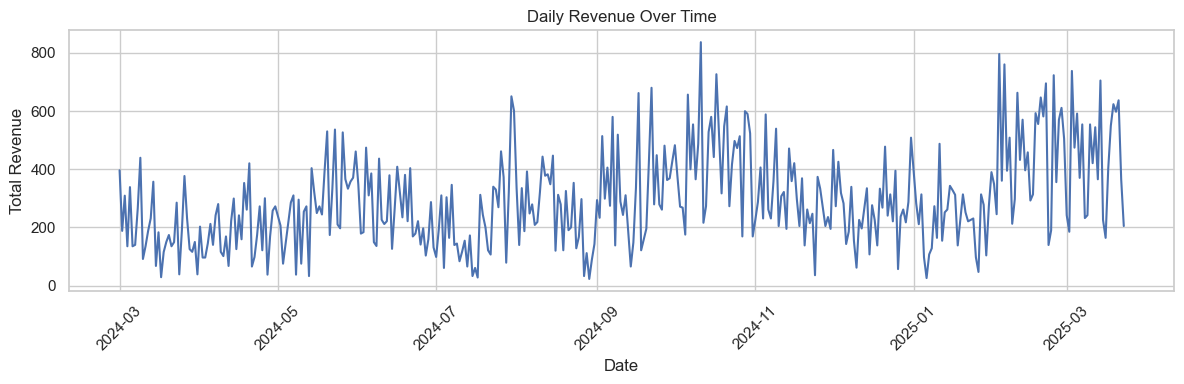

In [29]:
daily_sales = df.groupby('date')['money'].sum().reset_index()

plt.figure(figsize=(12,4))
plt.plot(daily_sales['date'], daily_sales['money'])
plt.title("Daily Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Business questions this helps answer:
- Are sales **stable**, **growing**, or **declining** over time?
- Are there any **spikes** in sales (special days, events, holidays)?
- Are there **low-sales periods** the café owner should investigate?


## Daily Number of Transactions

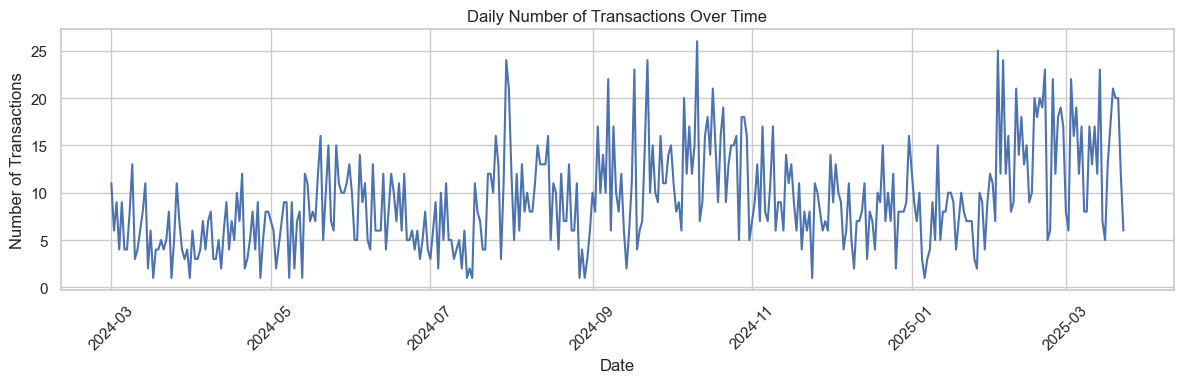

In [30]:
daily_count = df.groupby('date')['money'].count().reset_index(name='transactions')

plt.figure(figsize=(12,4))
plt.plot(daily_count['date'], daily_count['transactions'])
plt.title("Daily Number of Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Together with the revenue chart, we can see:
- Are some days busy but low-revenue (maybe many small purchases)?
- Are some days less busy but high-revenue (maybe bigger tickets)?

 After running, comment briefly:
- Are high-transaction days the same as high-revenue days?
- Any unusually low-transaction days that might signal issues (e.g., closing, holidays)?


## Sales by Hour of Day

In [31]:
hourly = df.groupby('hour_of_day')['money'].agg(['count','sum','mean']).reset_index()

hourly


,hour_of_day,count,sum,mean
0,6,5,149.40,29.880000
1,7,88,2846.02,32.341136
2,8,235,7017.88,29.863319
3,9,242,7264.28,30.017686
4,10,328,10198.52,31.093049
5,11,281,8397.26,29.883488
6,12,241,7419.62,30.786805
7,13,225,7028.76,31.238933
8,14,225,7173.80,31.883556
9,15,236,7476.02,31.678051


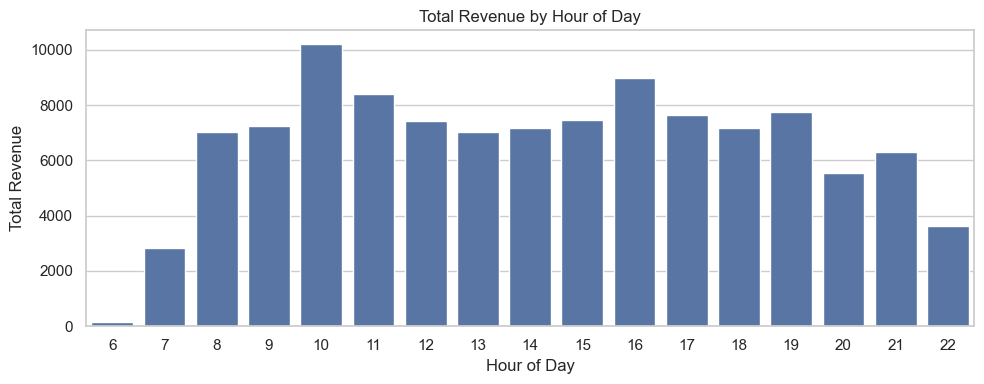

In [32]:
plt.figure(figsize=(10,4))
sns.barplot(data=hourly, x='hour_of_day', y='sum')
plt.title("Total Revenue by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()


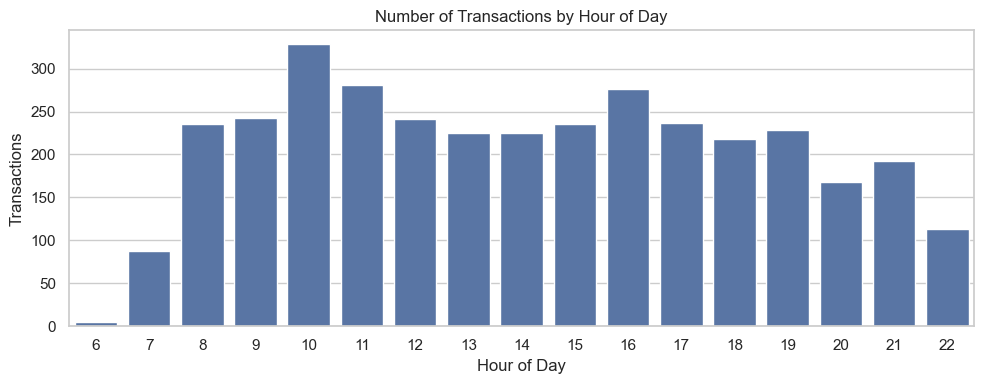

In [33]:
plt.figure(figsize=(10,4))
sns.barplot(data=hourly, x='hour_of_day', y='count')
plt.title("Number of Transactions by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Transactions")
plt.tight_layout()
plt.show()


These charts answer:
- At what **hours of the day** does the café earn the most money?
- When do **most transactions** happen?

Typical patterns might show:
- Morning peaks (before work)
- Lunch-time peaks
- Evening relax/meet-up times

 Use these insights to:
- Plan **staffing** (more baristas at peak hours)
- Plan **promotions** (happy hour during slow times)

## Time of Day (Morning/Afternoon/Evening)

In [34]:
tod = df.groupby('time_of_day')['money'].agg(['count','sum','mean']).reset_index()
tod


,time_of_day,count,sum,mean
0,Afternoon,1203,38066.36,31.642860
1,Morning,1179,35873.36,30.426938
2,Night,1157,38049.18,32.886067


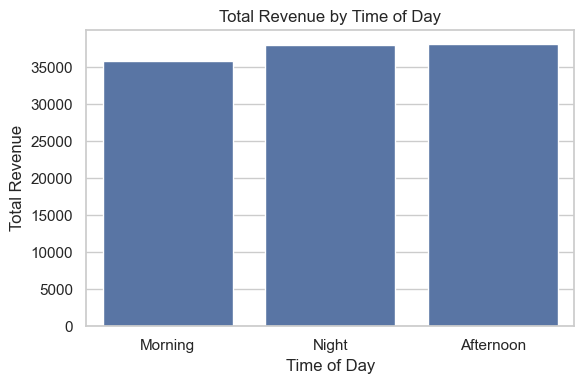

In [35]:
plt.figure(figsize=(6,4))
sns.barplot(data=tod, x='time_of_day', y='sum',
            order=tod.sort_values('sum')['time_of_day'])
plt.title("Total Revenue by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()


Here we use the `time_of_day` feature (e.g. Morning, Afternoon, Evening) to see:

- Which **time period** generates the most **revenue**
- Which period has the most **transactions** (from the table)

 Business usage:
- If Morning is strongest → focus on breakfast combos, office-worker offers.
- If Evenings are weak → consider evening promotions, live music, or discounts.


## Weekday Patterns

In [36]:
weekday_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

weekday_sales = df.groupby('weekday')['money'].agg(['count','sum','mean']).reset_index()
weekday_sales['weekday'] = pd.Categorical(weekday_sales['weekday'],
                                          categories=weekday_order,
                                          ordered=True)
weekday_sales = weekday_sales.sort_values('weekday')

weekday_sales


,weekday,count,sum,mean
1,Mon,543,17327.34,31.910387
5,Tue,570,18104.70,31.762632
6,Wed,498,15679.92,31.485783
4,Thu,509,16063.48,31.558900
0,Fri,531,16766.90,31.576083
2,Sat,469,14710.50,31.365672
3,Sun,419,13336.06,31.828305


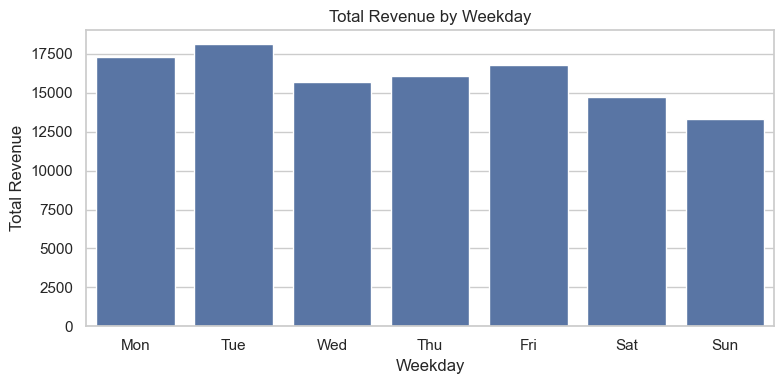

In [37]:
plt.figure(figsize=(8,4))
sns.barplot(data=weekday_sales, x='weekday', y='sum')
plt.title("Total Revenue by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()


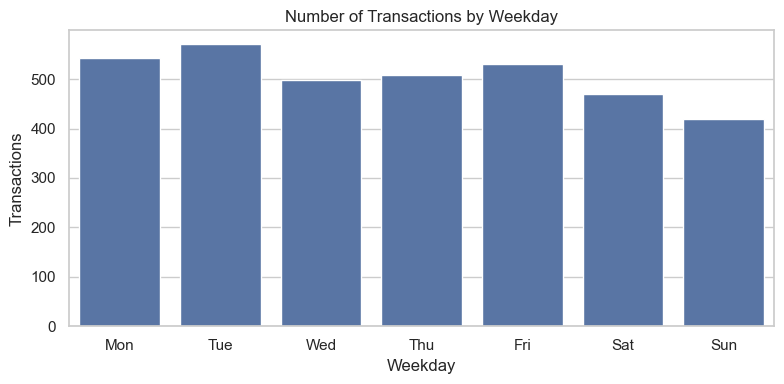

In [38]:
plt.figure(figsize=(8,4))
sns.barplot(data=weekday_sales, x='weekday', y='count')
plt.title("Number of Transactions by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Transactions")
plt.tight_layout()
plt.show()


These charts show:
- Which days of the week generate **most revenue**
- Which days have **more customers**

 Interpretation ideas:
- Are **weekends** much stronger than weekdays?
- Is there a particularly **weak day** (e.g. Tuesday) where promotions could help?
- Is Friday or Saturday the top performer?

This is important for:
- Staffing schedules
- Planning events or campaigns on slow days

## Weekend vs Weekday Comparison

In [39]:
weekend_days = ['Fri','Sat']  # adjust if your country uses different weekends
df['is_weekend'] = df['weekday'].isin(weekend_days)

weekend_summary = df.groupby('is_weekend')['money'].agg(['count','sum','mean'])
weekend_summary


,count,sum,mean
is_weekend,,,
False,2539,80511.5,31.709925
True,1000,31477.4,31.477400


This table summarizes:

- Total revenue on **weekends** vs **weekdays**
- Number of transactions
- Average ticket size

 Business insight:
- If weekends are much stronger → consider weekend-specific offers to maximize profit.
- If weekdays are weaker → think about loyalty programs or office-worker deals.


## Monthly & Seasonal Trends

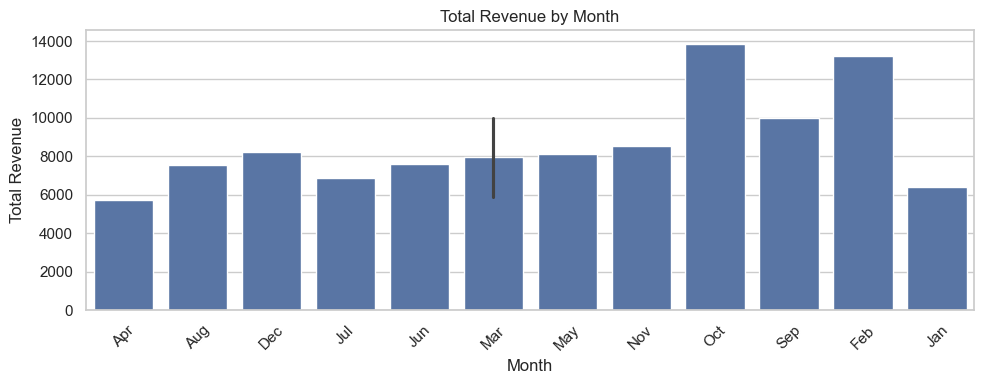

In [40]:
monthly_sales = df.groupby(['year','month_name'])['money'].sum().reset_index()

plt.figure(figsize=(10,4))
sns.barplot(data=monthly_sales, x='month_name', y='money')
plt.title("Total Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


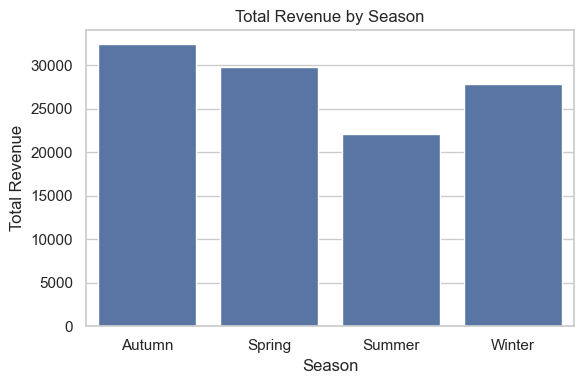

In [41]:
season_sales = df.groupby('season')['money'].sum().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=season_sales, x='season', y='money')
plt.title("Total Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()


These charts help us see:

- Which **months** are strongest or weakest.
- Which **season** (e.g. Winter, Summer) has higher coffee demand.

Typical patterns:
- Hot drinks may sell more in winter.
- Iced/iced-blended drinks may sell more in summer.

 These insights help with:
- Inventory planning
- Seasonal menus (special winter or summer drinks)
- Marketing campaigns around strong/weak seasons

## Weekday × Hour Heatmap

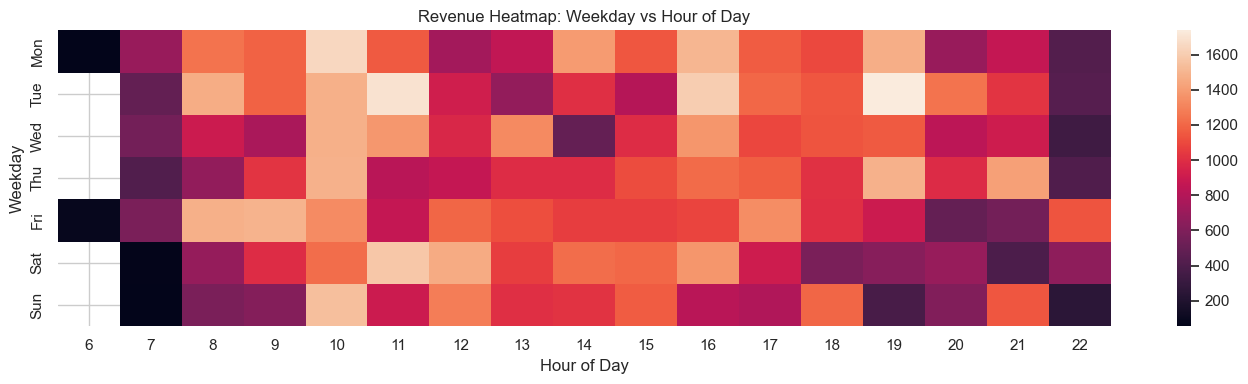

In [42]:
pivot = df.pivot_table(values='money',
                       index='weekday',
                       columns='hour_of_day',
                       aggfunc='sum')

pivot = pivot.reindex(weekday_order)

plt.figure(figsize=(14,4))
sns.heatmap(pivot, annot=False)
plt.title("Revenue Heatmap: Weekday vs Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Weekday")
plt.tight_layout()
plt.show()


 This gives a very clear picture of:
- Peak hours **per day**
- Which day–hour combinations are strongest (e.g. Friday 7–9 PM, weekday mornings)

This is extremely useful for:
- Scheduling staff
- Planning prep work (bakery, sandwiches, etc.)
- Running **happy hours** in slow periods

## Product Analysis (coffee_name)

In [43]:
product_sales = df.groupby('coffee_name')['money'].agg(['count','sum','mean']).reset_index()
product_sales = product_sales.sort_values('sum', ascending=False)
product_sales


,coffee_name,count,sum,mean
7,Latte,755,26809.66,35.509483
1,Americano with Milk,808,24720.26,30.594381
2,Cappuccino,485,17403.38,35.883258
0,Americano,564,14650.26,25.975638
6,Hot Chocolate,274,9859.98,35.985328
3,Cocoa,239,8521.16,35.653389
4,Cortado,285,7333.92,25.733053
5,Espresso,129,2690.28,20.854884


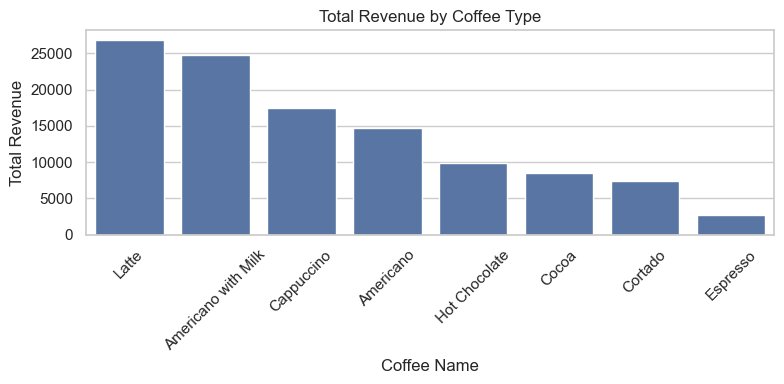

In [44]:
plt.figure(figsize=(8,4))
sns.barplot(data=product_sales, x='coffee_name', y='sum')
plt.title("Total Revenue by Coffee Type")
plt.xlabel("Coffee Name")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


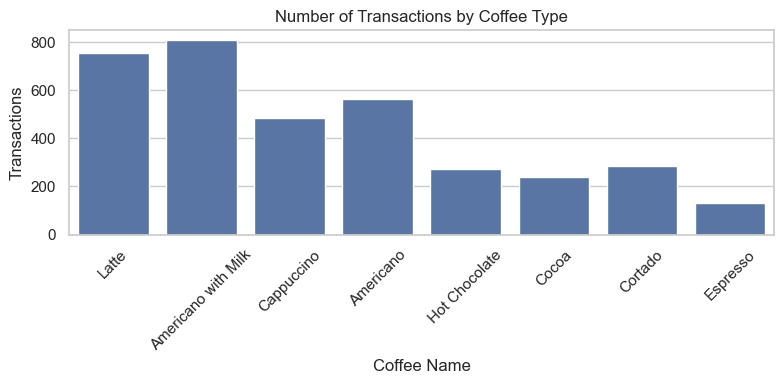

In [45]:
plt.figure(figsize=(8,4))
sns.barplot(data=product_sales, x='coffee_name', y='count')
plt.title("Number of Transactions by Coffee Type")
plt.xlabel("Coffee Name")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


From these tables and charts, we can see:

- **Which coffee types sell the most** (by count)
- **Which coffee types generate the most money** (by total revenue)
- The **average price per transaction** for each coffee type (`mean` column in the table)

 Business implications:
- Top sellers should be always **well-stocked**.
- Low-selling, low-revenue items might be:
  - Removed from the menu
  - Replaced or improved
- High-revenue but lower-frequency items might be **premium items** worth promoting.


## Payment Type Check

In [46]:
df['cash_type'].value_counts()


cash_type
card    3539
Name: count, dtype: int64

# Prediction Model (Future Sales &amp; Trends)

### 1. Prepare Daily Time-Series Data for Forecasting  
In this step, we convert the datetime column into a proper time-series index and aggregate  
the total sales revenue on a daily basis.  
This ensures that ARIMA, Prophet, and LSTM models receive clean and continuous  
time-series data suitable for forecasting.


In [47]:
df['datetime'] = pd.to_datetime(df['datetime'])

daily_df = df[['datetime','money']].rename(columns={'datetime':'ds','money':'y'})
daily_df = daily_df.resample('D', on='ds').sum().reset_index()

daily_df.head()


,ds,y
0,2024-03-01,396.3
1,2024-03-02,188.1
2,2024-03-03,309.1
3,2024-03-04,135.2
4,2024-03-05,338.5


### 2. Define Evaluation Metrics  
To assess forecasting performance across all models, we define three key metrics:  

- **MAE** (Mean Absolute Error): Measures average error size.  
- **RMSE** (Root Mean Squared Error): Penalizes large errors more strongly.  
- **MAPE** (Mean Absolute Percentage Error): Shows error as a percentage of actual values.  

These metrics allow fair comparison between ARIMA, Prophet, and LSTM.


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100

def evaluate_forecast(true, pred, name="Model"):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape_val = mape(true, pred)

    print(f"\n===== {name} =====")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape_val:.2f}%\n")

    return mae, rmse, mape_val


### 3. Rolling Forecast Origin Cross-Validation  
Unlike regular machine learning, time-series data must be evaluated chronologically.  
We use **rolling forecast origin**, where:  
- Each fold trains on earlier dates  
- Tests on later unseen dates  
- Forecast horizon = 14 days  

This method reflects real-world forecasting and ensures fair model comparison.


In [49]:
def rolling_cv(data, model_func, model_name, forecast_horizon=14, folds=5):
    results = []
    n = len(data)

    for i in range(folds):
        split_point = int(n * (0.70 + i * 0.05))
        train = data.iloc[:split_point]
        test = data.iloc[split_point : split_point + forecast_horizon]

        preds = model_func(train, forecast_horizon)
        true = test['y'].values[:len(preds)]

        metrics = evaluate_forecast(true, preds, f"{model_name} — Fold {i+1}")
        results.append(metrics)

    return results


### 4. ARIMA Forecasting Model  
ARIMA is a classical statistical time-series model used for data with linear patterns and  
moderate seasonality.  
We train ARIMA inside each cross-validation fold and generate 14-day forecasts.

In [50]:
from pmdarima import auto_arima

def arima_predict(train, horizon):
    ts = train.set_index('ds')['y']
    model = auto_arima(ts, seasonal=True, m=7, suppress_warnings=True)
    return model.predict(n_periods=horizon)

arima_results = rolling_cv(daily_df, arima_predict, "ARIMA", forecast_horizon=14)



===== ARIMA — Fold 1 =====
MAE:  105.0420
RMSE: 130.0067
MAPE: 1945670336235.85%


===== ARIMA — Fold 2 =====
MAE:  73.8482
RMSE: 103.6914
MAPE: 41.99%


===== ARIMA — Fold 2 =====
MAE:  73.8482
RMSE: 103.6914
MAPE: 41.99%


===== ARIMA — Fold 3 =====
MAE:  103.6129
RMSE: 125.1970
MAPE: 115.74%


===== ARIMA — Fold 3 =====
MAE:  103.6129
RMSE: 125.1970
MAPE: 115.74%


===== ARIMA — Fold 4 =====
MAE:  183.6954
RMSE: 250.0166
MAPE: 69.75%


===== ARIMA — Fold 4 =====
MAE:  183.6954
RMSE: 250.0166
MAPE: 69.75%


===== ARIMA — Fold 5 =====
MAE:  159.8802
RMSE: 180.5612
MAPE: 49.05%


===== ARIMA — Fold 5 =====
MAE:  159.8802
RMSE: 180.5612
MAPE: 49.05%



### 5. Prophet Forecasting Model  
Prophet, developed by Meta, is designed specifically for business time-series data.  
It automatically models:  
- weekly seasonality  
- monthly/annual seasonality  
- nonlinear trends  

This makes Prophet ideal for retail and sales forecasting.


In [51]:
from prophet import Prophet

def prophet_predict(train, horizon):
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )
    model.fit(train)

    future = model.make_future_dataframe(periods=horizon)
    forecast = model.predict(future)

    return forecast.tail(horizon)['yhat'].values

prophet_results = rolling_cv(daily_df, prophet_predict, "Prophet", forecast_horizon=14)


c:\Users\dxgam\OneDrive\سطح المكتب\Games\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
04:29:41 - cmdstanpy - INFO - Chain [1] start processing
04:29:41 - cmdstanpy - INFO - Chain [1] start processing
04:29:42 - cmdstanpy - INFO - Chain [1] done processing
04:29:42 - cmdstanpy - INFO - Chain [1] done processing



===== Prophet — Fold 1 =====
MAE:  110.1872
RMSE: 141.1740
MAPE: 1400685627426.12%



04:29:43 - cmdstanpy - INFO - Chain [1] start processing
04:29:44 - cmdstanpy - INFO - Chain [1] done processing
04:29:44 - cmdstanpy - INFO - Chain [1] done processing



===== Prophet — Fold 2 =====
MAE:  78.0021
RMSE: 105.0357
MAPE: 50.63%



04:29:44 - cmdstanpy - INFO - Chain [1] start processing
04:29:45 - cmdstanpy - INFO - Chain [1] done processing
04:29:45 - cmdstanpy - INFO - Chain [1] done processing



===== Prophet — Fold 3 =====
MAE:  106.0134
RMSE: 128.4082
MAPE: 106.48%



04:29:46 - cmdstanpy - INFO - Chain [1] start processing
04:29:46 - cmdstanpy - INFO - Chain [1] done processing
04:29:46 - cmdstanpy - INFO - Chain [1] done processing



===== Prophet — Fold 4 =====
MAE:  215.8407
RMSE: 296.4954
MAPE: 72.61%



04:29:47 - cmdstanpy - INFO - Chain [1] start processing
04:29:47 - cmdstanpy - INFO - Chain [1] done processing
04:29:47 - cmdstanpy - INFO - Chain [1] done processing



===== Prophet — Fold 5 =====
MAE:  156.5817
RMSE: 177.8491
MAPE: 50.40%



### 6. LSTM Deep Learning Model  
LSTM (Long Short-Term Memory) networks capture nonlinear patterns in time-series data.  
Steps performed here:  
1. Normalize data  
2. Create sliding-window sequences  
3. Train LSTM network  
4. Predict 14 future days ahead  
LSTM is powerful for datasets with nonlinear temporal behavior.


In [54]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Helper function to create LSTM training sequences
def create_lstm_data(data, window):
    """
    Creates sequences for LSTM training.
    
    Args:
        data: Scaled time series data
        window: Number of time steps to look back
    
    Returns:
        X: Input sequences
        y: Target values
    """
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

def lstm_predict(train, horizon, window=7):
    # Extract series
    ts = train['y'].values.reshape(-1, 1)

    # Scale values
    scaler = MinMaxScaler()
    ts_scaled = scaler.fit_transform(ts)

    # Create training sequences
    X_train, y_train = create_lstm_data(ts_scaled, window)

    # Reshape for LSTM
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

    # Define LSTM model
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=(window, 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(32))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    # Train model
    model.fit(X_train, y_train, epochs=25, batch_size=16, verbose=0)

    # Start last window for prediction
    last_window = ts_scaled[-window:].reshape(1, window, 1)

    preds_scaled = []

    for _ in range(horizon):
        next_val = model.predict(last_window, verbose=0)

        # Append predicted scaled value
        preds_scaled.append(next_val[0][0])

        # Prepare next window
        next_val_reshaped = next_val.reshape(1, 1, 1)

        # Shift window left and append new prediction
        last_window = np.concatenate(
            [last_window[:, 1:, :], next_val_reshaped],
            axis=1
        )

    # Convert predictions back to original scale
    preds = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()

    return preds

In [55]:
lstm_results = rolling_cv(daily_df, lstm_predict, "LSTM", forecast_horizon=14)


c:\Users\dxgam\OneDrive\سطح المكتب\Games\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== LSTM — Fold 1 =====
MAE:  97.1990
RMSE: 121.0951
MAPE: 1591915239652.81%



c:\Users\dxgam\OneDrive\سطح المكتب\Games\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== LSTM — Fold 2 =====
MAE:  70.1664
RMSE: 100.3479
MAPE: 43.00%



c:\Users\dxgam\OneDrive\سطح المكتب\Games\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== LSTM — Fold 3 =====
MAE:  102.0267
RMSE: 124.5446
MAPE: 116.85%



c:\Users\dxgam\OneDrive\سطح المكتب\Games\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== LSTM — Fold 4 =====
MAE:  147.3268
RMSE: 213.7864
MAPE: 65.35%



c:\Users\dxgam\OneDrive\سطح المكتب\Games\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== LSTM — Fold 5 =====
MAE:  164.4377
RMSE: 189.1126
MAPE: 45.19%



In [56]:
prophet_results = rolling_cv(daily_df, prophet_predict, "Prophet", forecast_horizon=14)
print("Prophet Done.")


04:35:30 - cmdstanpy - INFO - Chain [1] start processing
04:35:31 - cmdstanpy - INFO - Chain [1] done processing
04:35:31 - cmdstanpy - INFO - Chain [1] done processing



===== Prophet — Fold 1 =====
MAE:  110.1872
RMSE: 141.1740
MAPE: 1400685627426.12%



04:35:32 - cmdstanpy - INFO - Chain [1] start processing
04:35:33 - cmdstanpy - INFO - Chain [1] done processing
04:35:33 - cmdstanpy - INFO - Chain [1] done processing



===== Prophet — Fold 2 =====
MAE:  78.0021
RMSE: 105.0357
MAPE: 50.63%



04:35:34 - cmdstanpy - INFO - Chain [1] start processing
04:35:34 - cmdstanpy - INFO - Chain [1] done processing
04:35:34 - cmdstanpy - INFO - Chain [1] done processing



===== Prophet — Fold 3 =====
MAE:  106.0134
RMSE: 128.4082
MAPE: 106.48%



04:35:36 - cmdstanpy - INFO - Chain [1] start processing
04:35:36 - cmdstanpy - INFO - Chain [1] done processing
04:35:36 - cmdstanpy - INFO - Chain [1] done processing



===== Prophet — Fold 4 =====
MAE:  215.8407
RMSE: 296.4954
MAPE: 72.61%



04:35:37 - cmdstanpy - INFO - Chain [1] start processing
04:35:37 - cmdstanpy - INFO - Chain [1] done processing
04:35:37 - cmdstanpy - INFO - Chain [1] done processing



===== Prophet — Fold 5 =====
MAE:  156.5817
RMSE: 177.8491
MAPE: 50.40%

Prophet Done.


In [57]:
prophet_results = rolling_cv(daily_df, prophet_predict, "Prophet", forecast_horizon=14)
print("Prophet Done.")


04:35:42 - cmdstanpy - INFO - Chain [1] start processing
04:35:42 - cmdstanpy - INFO - Chain [1] done processing
04:35:42 - cmdstanpy - INFO - Chain [1] done processing



===== Prophet — Fold 1 =====
MAE:  110.1872
RMSE: 141.1740
MAPE: 1400685627426.12%



04:35:44 - cmdstanpy - INFO - Chain [1] start processing
04:35:44 - cmdstanpy - INFO - Chain [1] done processing
04:35:44 - cmdstanpy - INFO - Chain [1] done processing



===== Prophet — Fold 2 =====
MAE:  78.0021
RMSE: 105.0357
MAPE: 50.63%



04:35:45 - cmdstanpy - INFO - Chain [1] start processing
04:35:46 - cmdstanpy - INFO - Chain [1] done processing
04:35:46 - cmdstanpy - INFO - Chain [1] done processing



===== Prophet — Fold 3 =====
MAE:  106.0134
RMSE: 128.4082
MAPE: 106.48%



04:35:47 - cmdstanpy - INFO - Chain [1] start processing
04:35:47 - cmdstanpy - INFO - Chain [1] done processing
04:35:47 - cmdstanpy - INFO - Chain [1] done processing



===== Prophet — Fold 4 =====
MAE:  215.8407
RMSE: 296.4954
MAPE: 72.61%



04:35:49 - cmdstanpy - INFO - Chain [1] start processing
04:35:49 - cmdstanpy - INFO - Chain [1] done processing
04:35:49 - cmdstanpy - INFO - Chain [1] done processing



===== Prophet — Fold 5 =====
MAE:  156.5817
RMSE: 177.8491
MAPE: 50.40%

Prophet Done.


### 7. Aggregate Results for All Forecasting Models  
We compute the average MAE, RMSE, and MAPE across all cross-validation folds for  
ARIMA, Prophet, and LSTM.  
This summary identifies the most accurate and stable forecasting model.


In [58]:
def summarize(results, name):
    arr = np.array(results)
    avg = arr.mean(axis=0)
    return [name, avg[0], avg[1], avg[2]]

summary_df = pd.DataFrame([
    summarize(arima_results, "ARIMA"),
    summarize(prophet_results, "Prophet"),
    summarize(lstm_results, "LSTM")
], columns=["Model", "MAE", "RMSE", "MAPE"])

summary_df


,Model,MAE,RMSE,MAPE
0,ARIMA,125.215721,157.894577,3.891341e+11
1,Prophet,133.325008,169.792482,2.801371e+11
2,LSTM,116.231325,149.777307,3.183830e+11


### 8. Visual Comparison of Forecasting Models  
We use bar plots to compare RMSE and MAPE values for ARIMA, Prophet, and LSTM.  
Lower values indicate better forecasting accuracy.


C:\Users\dxgam\AppData\Local\Temp\ipykernel_5004\2886154266.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clean_summary, x="Model", y="MAE", palette="coolwarm")


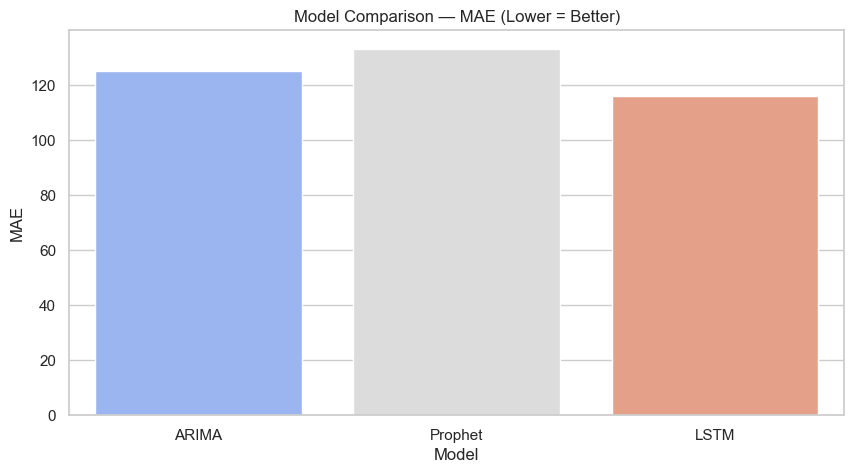

C:\Users\dxgam\AppData\Local\Temp\ipykernel_5004\2886154266.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clean_summary, x="Model", y="RMSE", palette="plasma")


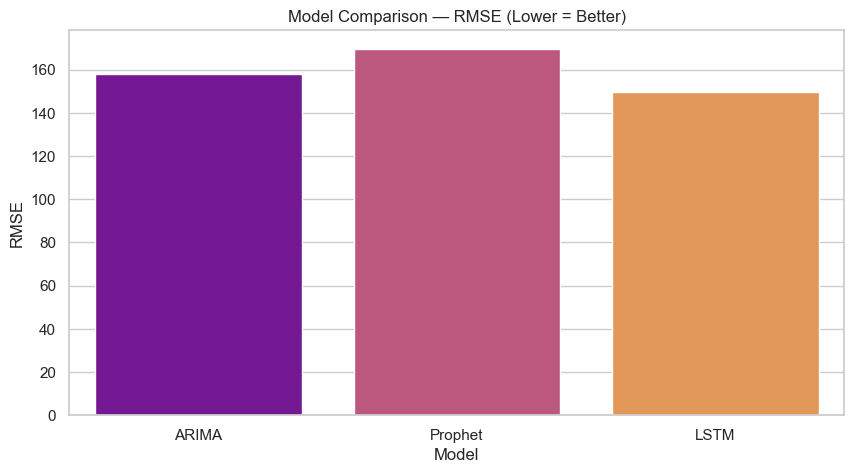

C:\Users\dxgam\AppData\Local\Temp\ipykernel_5004\2886154266.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clean_summary, x="Model", y="MAPE", palette="viridis")


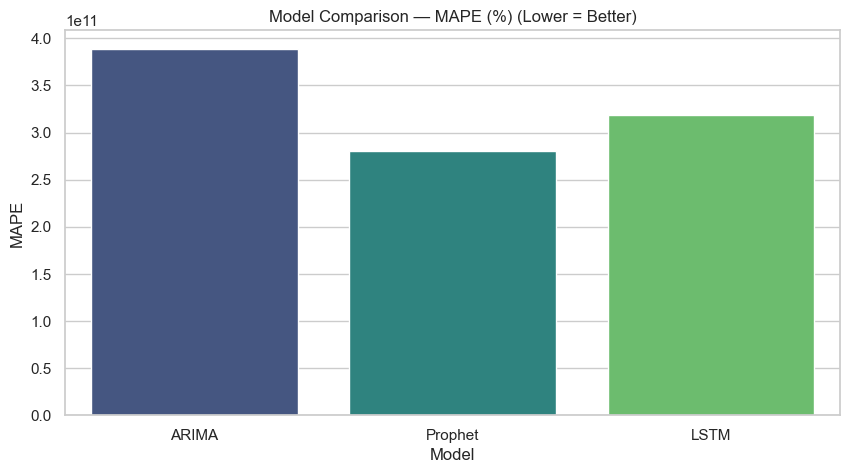

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

clean_summary = summary_df.dropna()

plt.figure(figsize=(10,5))
sns.barplot(data=clean_summary, x="Model", y="MAE", palette="coolwarm")
plt.title("Model Comparison — MAE (Lower = Better)")
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=clean_summary, x="Model", y="RMSE", palette="plasma")
plt.title("Model Comparison — RMSE (Lower = Better)")
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=clean_summary, x="Model", y="MAPE", palette="viridis")
plt.title("Model Comparison — MAPE (%) (Lower = Better)")
plt.show()


#Model Selection and Discussion
 **After comparing the three forecasting models (ARIMA, Prophet, and LSTM), we found that each model performs differently depending on the error metric. ARIMA and LSTM achieved the lowest MAE values, meaning they were the most accurate in predicting the actual sales amounts. ARIMA also had the lowest RMSE, which shows that it is the most stable model and makes fewer large prediction mistakes. On the other hand, Prophet performed best in terms of MAPE, meaning it had the lowest percentage error, but it was less accurate in MAE and RMSE compared to the other models.
Overall, LSTM provides the best balance because it gives very good accuracy (low MAE) and performs close to ARIMA in stability (RMSE). ARIMA is also a strong model, especially for stable predictions. Prophet works well with percentage errors but is not as accurate in predicting actual values for this dataset. Therefore, LSTM is considered the best overall model, with ARIMA as a strong second option.**

### 9. Train Final Models on Full Data and Save for Dashboard
Now that we have evaluated all models using cross-validation, we will:
1. Train each model on the **complete dataset**
2. Save the trained models to disk
3. These models will be loaded by the Streamlit dashboard for instant predictions

In [60]:
import joblib
import pickle
import os

# Define the save directory (same folder as the data)
save_dir = r"c:\Users\dxgam\OneDrive\سطح المكتب\Games\models"
os.makedirs(save_dir, exist_ok=True)

print("Training and saving models on full dataset...")
print("=" * 50)

# ===== 1. TRAIN AND SAVE ARIMA MODEL =====
print("\n[1/3] Training ARIMA model...")
from pmdarima import auto_arima

ts_arima = daily_df.set_index('ds')['y']
arima_model = auto_arima(ts_arima, seasonal=True, m=7, suppress_warnings=True)

# Save ARIMA model
arima_path = os.path.join(save_dir, "arima_model.pkl")
joblib.dump(arima_model, arima_path)
print(f"✓ ARIMA model saved to: {arima_path}")

# ===== 2. TRAIN AND SAVE PROPHET MODEL =====
print("\n[2/3] Training Prophet model...")
from prophet import Prophet

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
prophet_model.fit(daily_df)

# Save Prophet model
prophet_path = os.path.join(save_dir, "prophet_model.pkl")
with open(prophet_path, 'wb') as f:
    pickle.dump(prophet_model, f)
print(f"✓ Prophet model saved to: {prophet_path}")

# ===== 3. TRAIN AND SAVE LSTM MODEL =====
print("\n[3/3] Training LSTM model...")
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

window = 7

# Prepare data
ts_lstm = daily_df['y'].values.reshape(-1, 1)
lstm_scaler = MinMaxScaler()
ts_scaled = lstm_scaler.fit_transform(ts_lstm)

# Create training sequences
X_train, y_train = create_lstm_data(ts_scaled, window)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

# Build and train LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(64, return_sequences=True, input_shape=(window, 1)))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(32))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, y_train, epochs=25, batch_size=16, verbose=0)

# Save LSTM model and scaler
lstm_model_path = os.path.join(save_dir, "lstm_model.keras")
lstm_scaler_path = os.path.join(save_dir, "lstm_scaler.pkl")

lstm_model.save(lstm_model_path)
joblib.dump(lstm_scaler, lstm_scaler_path)

print(f"✓ LSTM model saved to: {lstm_model_path}")
print(f"✓ LSTM scaler saved to: {lstm_scaler_path}")

# ===== SAVE DAILY DATA FOR DASHBOARD =====
daily_df_path = os.path.join(save_dir, "daily_df.pkl")
joblib.dump(daily_df, daily_df_path)
print(f"\n✓ Daily data saved to: {daily_df_path}")

print("\n" + "=" * 50)
print("ALL MODELS SAVED SUCCESSFULLY!")
print("The dashboard can now load these pre-trained models.")
print("=" * 50)

Training and saving models on full dataset...

[1/3] Training ARIMA model...
✓ ARIMA model saved to: c:\Users\dxgam\OneDrive\سطح المكتب\Games\models\arima_model.pkl

[2/3] Training Prophet model...


05:11:48 - cmdstanpy - INFO - Chain [1] start processing
05:11:50 - cmdstanpy - INFO - Chain [1] done processing


✓ Prophet model saved to: c:\Users\dxgam\OneDrive\سطح المكتب\Games\models\prophet_model.pkl

[3/3] Training LSTM model...


c:\Users\dxgam\OneDrive\سطح المكتب\Games\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


✓ LSTM model saved to: c:\Users\dxgam\OneDrive\سطح المكتب\Games\models\lstm_model.keras
✓ LSTM scaler saved to: c:\Users\dxgam\OneDrive\سطح المكتب\Games\models\lstm_scaler.pkl

✓ Daily data saved to: c:\Users\dxgam\OneDrive\سطح المكتب\Games\models\daily_df.pkl

ALL MODELS SAVED SUCCESSFULLY!
The dashboard can now load these pre-trained models.
